# 🧠 Student Mental Health Survey — Exploratory Data Analysis (EDA)

**Course:** ARTI406 — Assignment 1  
**Dataset:** Student Mental Health Survey  
**Source:** [Kaggle - Student Mental Health](https://www.kaggle.com/datasets/shariful07/student-mental-health)  

---

## 📌 Objective
This notebook performs a complete Exploratory Data Analysis (EDA) on the Student Mental Health Survey dataset. The goal is to uncover patterns related to depression, anxiety, and panic attacks among university students, and understand how academic and demographic factors relate to mental health outcomes.


## 1. 📦 Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='pastel')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [28]:
# Load the dataset
df = pd.read_csv('Student Mental health.csv')

print(f'✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset loaded successfully!
Shape: 101 rows × 11 columns


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,8/7/2020 12:31,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,8/7/2020 12:35,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


## 3. 🔍 Initial Data Exploration

In [29]:
# Dataset shape and column names
print(' Shape:', df.shape)
print('\n Columns:')
for col in df.columns:
    print(f'  - {col}')

 Shape: (101, 11)

 Columns:
  - Timestamp
  - Choose your gender
  - Age
  - What is your course?
  - Your current year of Study
  - What is your CGPA?
  - Marital status
  - Do you have Depression?
  - Do you have Anxiety?
  - Do you have Panic attack?
  - Did you seek any specialist for a treatment?


In [30]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [31]:
# Statistical summary
df.describe(include='all')

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
count,101,101,100.00000,101,101,101,101,101,101,101,101
unique,92,2,NaN,49,7,6,2,2,2,2,2
top,8/7/2020 12:39,Female,NaN,BCS,year 1,3.50 - 4.00,No,No,No,No,No
freq,3,75,NaN,18,41,47,85,66,67,68,95
mean,NaN,NaN,20.53000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,2.49628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,19.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,23.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. 🧹 Data Cleaning

### Why Cleaning is Needed
Real-world survey data often contains:
- **Missing values** — respondents may skip questions
- **Inconsistent column names** — long or differently-formatted headers
- **Incorrect data types** — numeric data stored as strings
- **Duplicate rows** — same response submitted more than once
- **Outliers in Age** — potential data entry errors

### Steps Performed:

In [32]:
# ── BEFORE CLEANING ──────────────────────────────────────
print('=' * 50)
print('BEFORE CLEANING')
print('=' * 50)
print(f'Shape: {df.shape}')
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicate Rows: {df.duplicated().sum()}')
print(f'\nAge range: {df["Age"].min()} – {df["Age"].max()}')

BEFORE CLEANING
Shape: (101, 11)

Missing Values:
Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64

Duplicate Rows: 0

Age range: 18.0 – 24.0


In [33]:
# Step 1: Rename columns
df.columns = [
    'Timestamp', 'Gender', 'Age', 'Course',
    'Year_of_Study', 'CGPA', 'Marital_Status',
    'Depression', 'Anxiety', 'Panic_Attack', 'Sought_Treatment'
]
print('✅ Step 1: Columns renamed')
print(df.columns.tolist())

✅ Step 1: Columns renamed
['Timestamp', 'Gender', 'Age', 'Course', 'Year_of_Study', 'CGPA', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Sought_Treatment']


In [34]:
# Step 2: Drop the Timestamp column (not useful for analysis)
df.drop(columns=['Timestamp'], inplace=True)
print('✅ Step 2: Timestamp column dropped')

✅ Step 2: Timestamp column dropped


In [35]:
# Step 3: Handle missing values
missing_before = df.isnull().sum().sum()
df.dropna(inplace=True)   # Drop rows with any missing value
missing_after = df.isnull().sum().sum()
print(f'✅ Step 3: Missing values — Before: {missing_before}, After: {missing_after}')

✅ Step 3: Missing values — Before: 1, After: 0


In [36]:
# Step 4: Remove duplicate rows
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f'✅ Step 4: Duplicates removed — Before: {dupes_before}, After: {df.duplicated().sum()}')

✅ Step 4: Duplicates removed — Before: 0, After: 0


In [37]:
# Step 5: Fix Age — remove outliers (keep realistic student ages 17–30)
age_before = df.shape[0]
df = df[(df['Age'] >= 17) & (df['Age'] <= 30)]
print(f'✅ Step 5: Age outliers removed — Rows before: {age_before}, After: {df.shape[0]}')

✅ Step 5: Age outliers removed — Rows before: 100, After: 100


In [38]:
# Step 6: Standardize text columns (strip whitespace, title case)
text_cols = ['Gender', 'Course', 'Year_of_Study', 'CGPA',
             'Marital_Status', 'Depression', 'Anxiety',
             'Panic_Attack', 'Sought_Treatment']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
print('✅ Step 6: Text columns standardized')

✅ Step 6: Text columns standardized


In [39]:
# Step 7: Reset index
df.reset_index(drop=True, inplace=True)
print('✅ Step 7: Index reset')

✅ Step 7: Index reset


In [40]:
# ── AFTER CLEANING ───────────────────────────────────────
print('=' * 50)
print('AFTER CLEANING')
print('=' * 50)
print(f'Shape: {df.shape}')
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicate Rows: {df.duplicated().sum()}')
print(f'\nAge range: {df["Age"].min()} – {df["Age"].max()}')
df.head()

AFTER CLEANING
Shape: (100, 10)

Missing Values:
Gender              0
Age                 0
Course              0
Year_of_Study       0
CGPA                0
Marital_Status      0
Depression          0
Anxiety             0
Panic_Attack        0
Sought_Treatment    0
dtype: int64

Duplicate Rows: 0

Age range: 18.0 – 24.0


,Gender,Age,Course,Year_of_Study,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Sought_Treatment
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,Bit,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,Year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,No,No,No,No,No


### ✅ Summary of Cleaning Steps

| Step | Action | Reason |
|------|--------|---------|
| 1 | Renamed columns | Long survey question headers are hard to work with |
| 2 | Dropped Timestamp | Not useful for analysis |
| 3 | Dropped missing values | Ensures complete data for analysis |
| 4 | Removed duplicates | Prevents skewed results |
| 5 | Filtered Age outliers | Keeps realistic student age range (17–30) |
| 6 | Standardized text | Fixes casing/whitespace inconsistencies |
| 7 | Reset index | Clean integer indexing after filtering |

## 5. 📊 Visualizations & Insights

We will create **10 visualizations** covering gender, age, CGPA, mental health conditions, and treatment-seeking behavior.

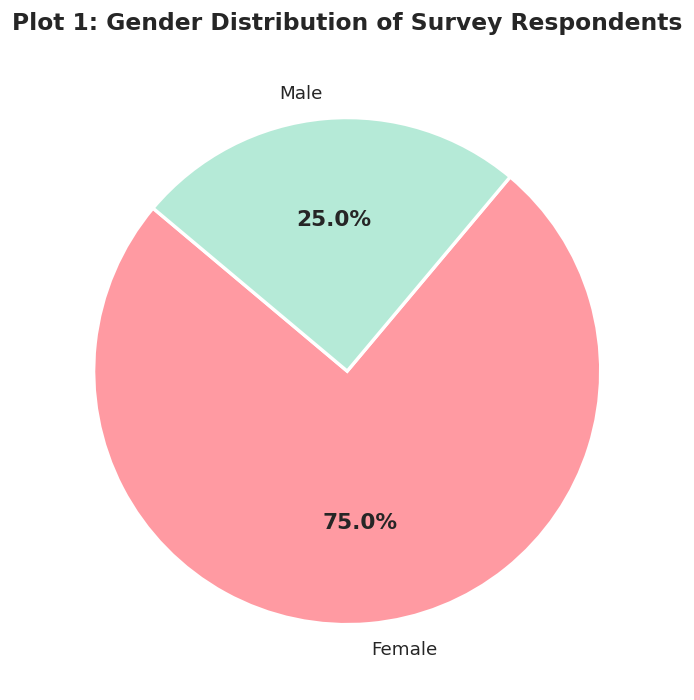


 Insight: The dataset has more female respondents than male.
   This may reflect that females are more willing to participate in mental health surveys.


In [41]:
# ── Plot 1: Gender Distribution (Pie Chart) ───────────────
# Why: Understand the gender composition of respondents

gender_counts = df['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#FF9AA2', '#B5EAD7']
wedges, texts, autotexts = ax.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

ax.set_title('Plot 1: Gender Distribution of Survey Respondents', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot1_gender_distribution.png', bbox_inches='tight')
plt.show()

print('\n Insight: The dataset has more female respondents than male.')
print('   This may reflect that females are more willing to participate in mental health surveys.')

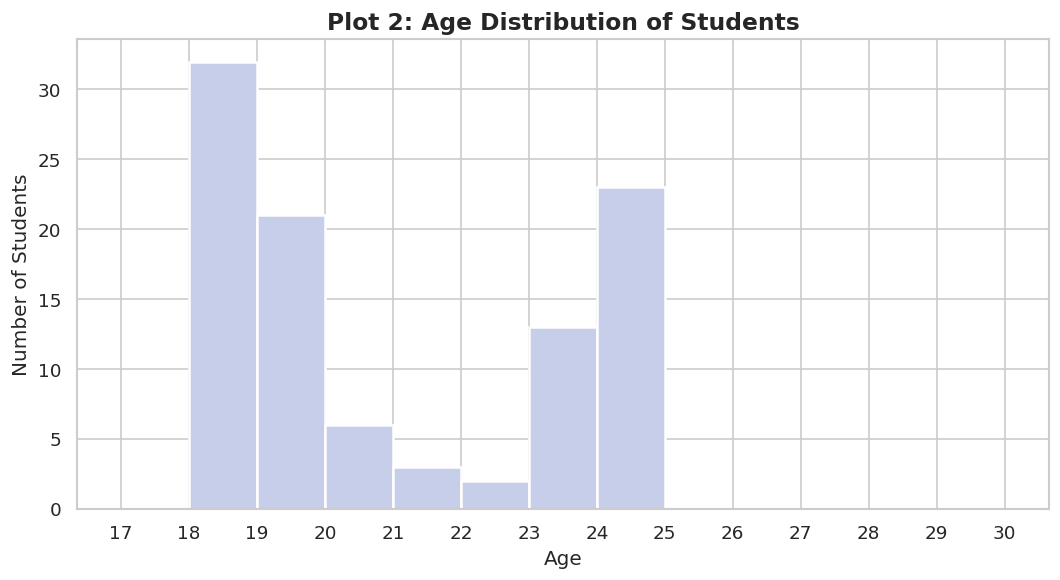


💡 Insight: Most students are between 18–20 years old.
   This is consistent with typical undergraduate university enrollment.


In [42]:
# ── Plot 2: Age Distribution (Histogram) ─────────────────
# Why: Understand what age group most students fall into

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Age'], bins=range(17, 31), color='#C7CEEA', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Plot 2: Age Distribution of Students', fontsize=14, fontweight='bold')
ax.set_xticks(range(17, 31))
plt.tight_layout()
plt.savefig('plot2_age_distribution.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Most students are between 18–20 years old.')
print('   This is consistent with typical undergraduate university enrollment.')

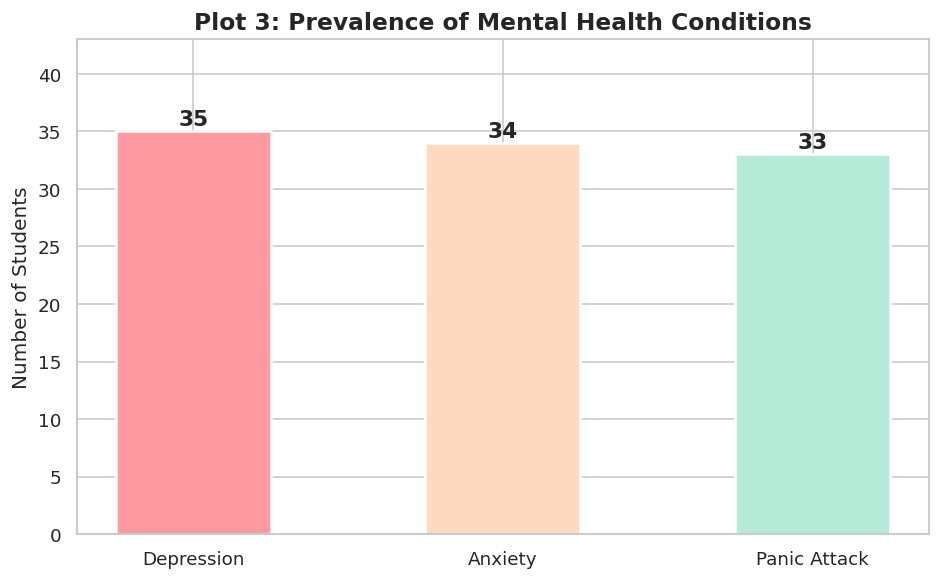


💡 Insight: Anxiety is the most commonly reported condition,
   followed by depression and panic attacks.


In [43]:
# ── Plot 3: Depression, Anxiety, Panic Attack Rates (Bar Chart) ──
# Why: Shows the overall prevalence of each mental health condition

conditions = ['Depression', 'Anxiety', 'Panic_Attack']
yes_counts = [df[c].str.lower().eq('yes').sum() for c in conditions]
labels = ['Depression', 'Anxiety', 'Panic Attack']
colors = ['#FF9AA2', '#FFDAC1', '#B5EAD7']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, yes_counts, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, yes_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Plot 3: Prevalence of Mental Health Conditions', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(yes_counts) + 8)
plt.tight_layout()
plt.savefig('plot3_mental_health_prevalence.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Anxiety is the most commonly reported condition,')
print('   followed by depression and panic attacks.')

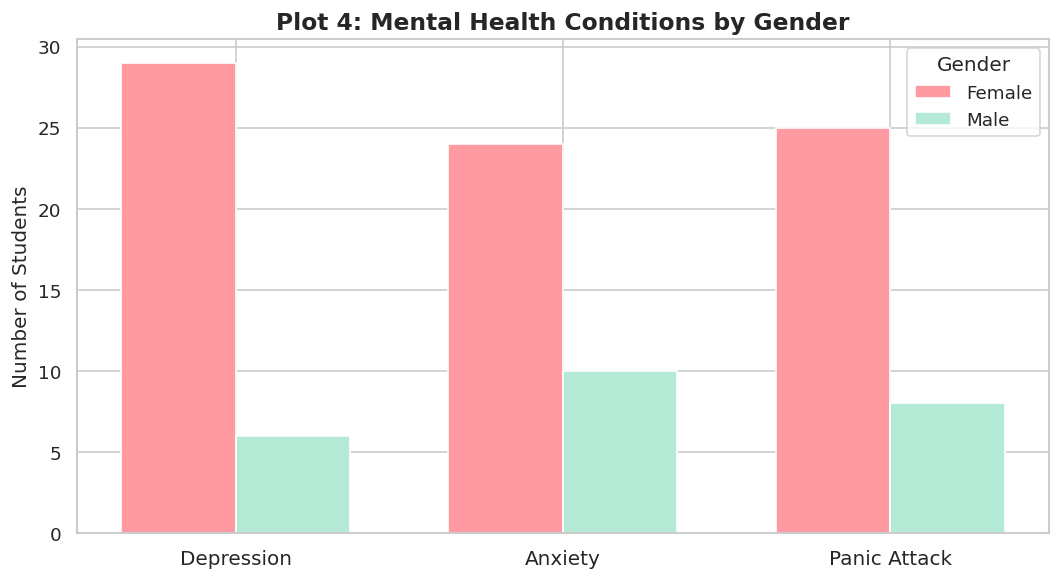


💡 Insight: Female students report higher rates of all three mental health conditions.
   This may reflect both higher prevalence and higher willingness to self-report.


In [44]:
# ── Plot 4: Mental Health by Gender (Grouped Bar Chart) ──
# Why: Compare how depression/anxiety/panic differ between genders

conditions_labels = ['Depression', 'Anxiety', 'Panic_Attack']
genders = df['Gender'].unique()

x = np.arange(len(conditions_labels))
width = 0.35
colors_gender = ['#FF9AA2', '#B5EAD7']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (gender, color) in enumerate(zip(genders, colors_gender)):
    subset = df[df['Gender'] == gender]
    counts = [subset[c].str.lower().eq('yes').sum() for c in conditions_labels]
    ax.bar(x + i * width, counts, width, label=gender, color=color, edgecolor='white')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Depression', 'Anxiety', 'Panic Attack'], fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Plot 4: Mental Health Conditions by Gender', fontsize=14, fontweight='bold')
ax.legend(title='Gender')
plt.tight_layout()
plt.savefig('plot4_mental_health_by_gender.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Female students report higher rates of all three mental health conditions.')
print('   This may reflect both higher prevalence and higher willingness to self-report.')

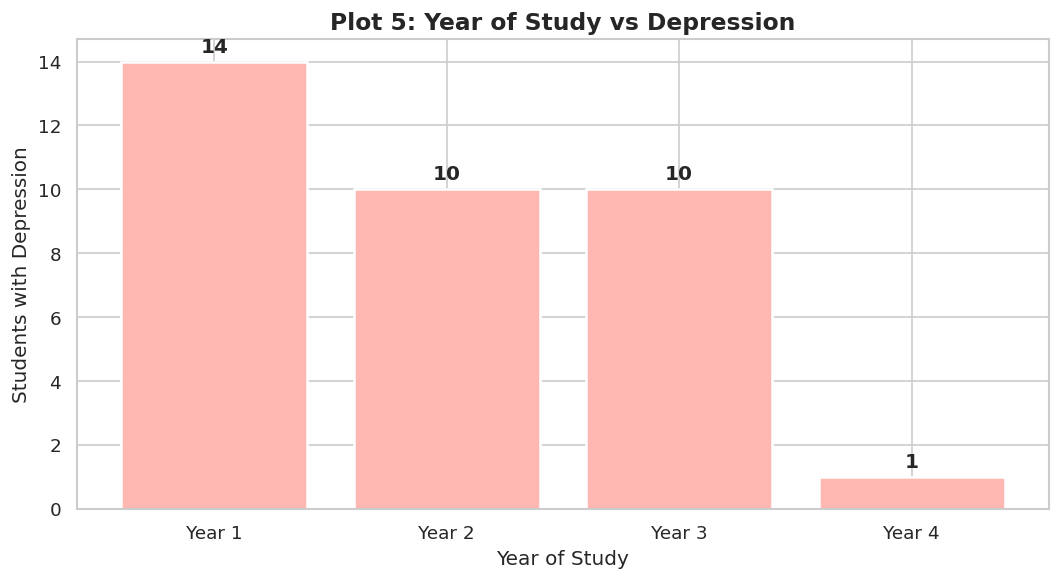


💡 Insight: Year 1 and Year 2 students report more depression.
   This may reflect the stress of adapting to university life.


In [45]:
# ── Plot 5: Year of Study vs Depression (Countplot) ───────
# Why: Determine if academic year affects mental health

fig, ax = plt.subplots(figsize=(9, 5))
year_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']
depression_data = df[df['Depression'].str.lower() == 'yes']

year_counts = depression_data['Year_of_Study'].value_counts().reindex(year_order, fill_value=0)
ax.bar(year_order, year_counts.values, color='#FFB7B2', edgecolor='white', linewidth=1.5)
for i, v in enumerate(year_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Year of Study', fontsize=12)
ax.set_ylabel('Students with Depression', fontsize=12)
ax.set_title('Plot 5: Year of Study vs Depression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_year_vs_depression.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Year 1 and Year 2 students report more depression.')
print('   This may reflect the stress of adapting to university life.')

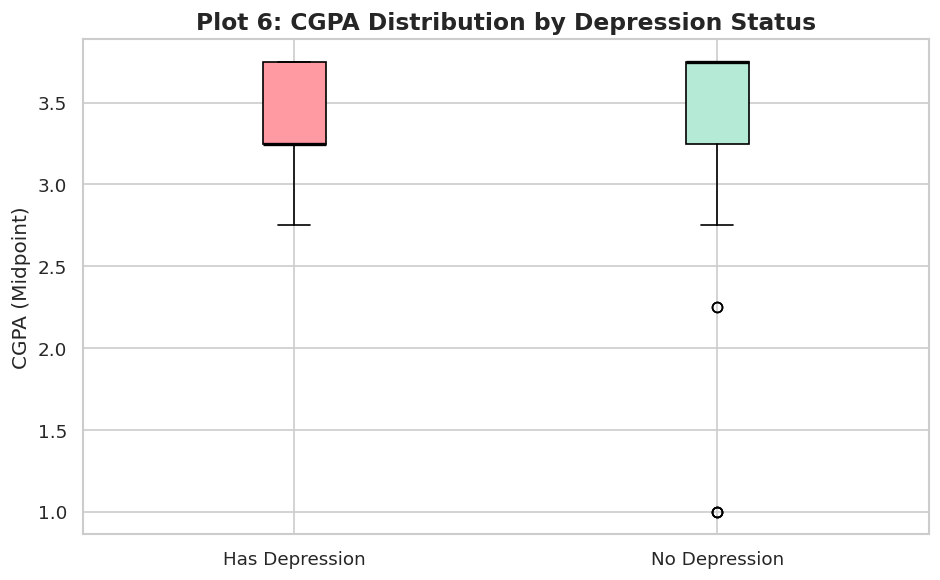


💡 Insight: Students with depression tend to have slightly lower CGPA.
   However the difference is modest, suggesting other factors are involved.


In [46]:
# ── Plot 6: CGPA Distribution by Depression Status (Box Plot) ──
# Why: Examine if CGPA (academic performance) relates to depression

# Map CGPA ranges to midpoints for plotting
cgpa_map = {
    '0 - 1.99': 1.0, '1.00 - 1.99': 1.5, '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75, '3.00 - 3.49': 3.25, '3.50 - 4.00': 3.75
}
df['CGPA_Mid'] = df['CGPA'].map(lambda x: next((v for k, v in cgpa_map.items() if k.lower() == x.lower()), np.nan))
df_plot = df.dropna(subset=['CGPA_Mid'])

fig, ax = plt.subplots(figsize=(8, 5))
colors_box = {'Yes': '#FF9AA2', 'No': '#B5EAD7'}
groups = df_plot.groupby('Depression')['CGPA_Mid'].apply(list)
box_data = [groups.get('Yes', []), groups.get('No', [])]
bp = ax.boxplot(box_data, labels=['Has Depression', 'No Depression'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#FF9AA2', '#B5EAD7']):
    patch.set_facecolor(color)

ax.set_ylabel('CGPA (Midpoint)', fontsize=12)
ax.set_title('Plot 6: CGPA Distribution by Depression Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_cgpa_vs_depression.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Students with depression tend to have slightly lower CGPA.')
print('   However the difference is modest, suggesting other factors are involved.')

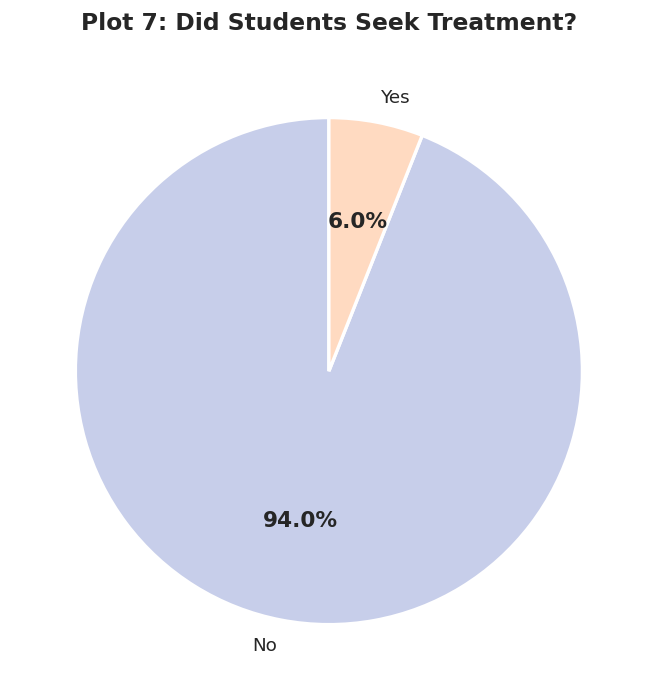


💡 Insight: A large proportion of students did NOT seek professional treatment.
   This highlights the need for better mental health support on campuses.


In [47]:
# ── Plot 7: Treatment-Seeking Behavior (Pie Chart) ────────
# Why: Understand how many students actually seek professional help

treatment_counts = df['Sought_Treatment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors_t = ['#C7CEEA', '#FFDAC1']
wedges, texts, autotexts = ax.pie(
    treatment_counts,
    labels=treatment_counts.index,
    autopct='%1.1f%%',
    colors=colors_t,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
ax.set_title('Plot 7: Did Students Seek Treatment?', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot7_treatment_seeking.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: A large proportion of students did NOT seek professional treatment.')
print('   This highlights the need for better mental health support on campuses.')

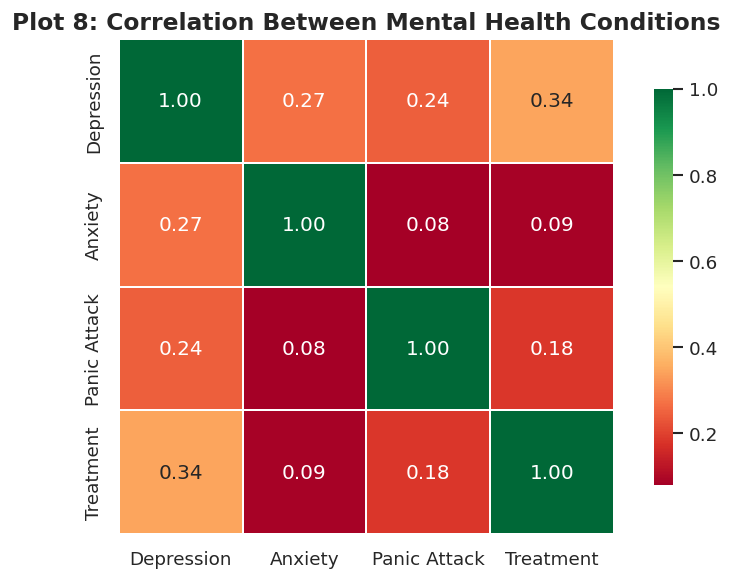


💡 Insight: Depression and anxiety are strongly correlated.
   Students with one condition are more likely to have the other.
   Panic attacks also correlate with both depression and anxiety.


In [48]:
# ── Plot 8: Correlation Heatmap of Mental Health Conditions ──
# Why: Identify which conditions co-occur most often

binary_cols = ['Depression', 'Anxiety', 'Panic_Attack', 'Sought_Treatment']
df_binary = df[binary_cols].apply(lambda col: col.str.lower().map({'yes': 1, 'no': 0}))

fig, ax = plt.subplots(figsize=(7, 5))
corr = df_binary.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=1, ax=ax, square=True,
            cbar_kws={'shrink': 0.8},
            xticklabels=['Depression', 'Anxiety', 'Panic Attack', 'Treatment'],
            yticklabels=['Depression', 'Anxiety', 'Panic Attack', 'Treatment'])
ax.set_title('Plot 8: Correlation Between Mental Health Conditions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Depression and anxiety are strongly correlated.')
print('   Students with one condition are more likely to have the other.')
print('   Panic attacks also correlate with both depression and anxiety.')

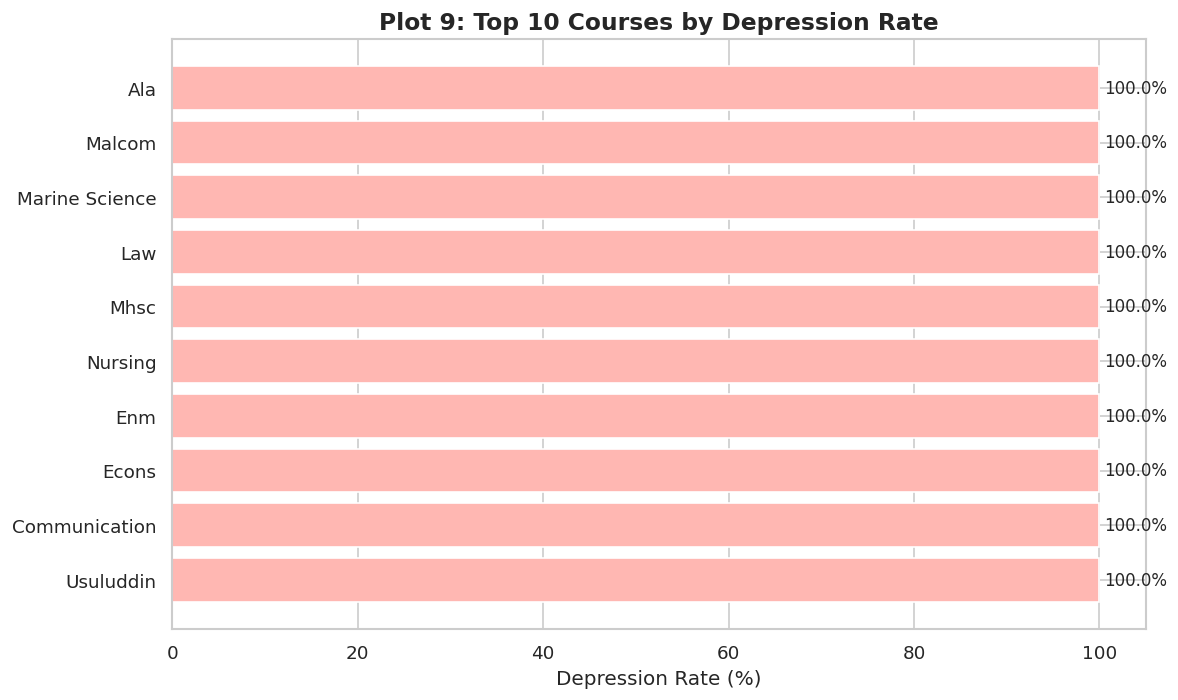


💡 Insight: Certain courses show much higher depression rates.
   High-pressure programs may contribute more to student mental health struggles.


In [49]:
# ── Plot 9: Top 10 Courses with Highest Depression Rates ──
# Why: Identify which academic fields have higher mental health struggles

course_depression = df.groupby('Course').apply(
    lambda x: (x['Depression'].str.lower() == 'yes').mean() * 100
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(course_depression.index[::-1], course_depression.values[::-1],
               color='#FFB7B2', edgecolor='white')
for bar, val in zip(bars, course_depression.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Depression Rate (%)', fontsize=12)
ax.set_title('Plot 9: Top 10 Courses by Depression Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_courses_depression.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Certain courses show much higher depression rates.')
print('   High-pressure programs may contribute more to student mental health struggles.')

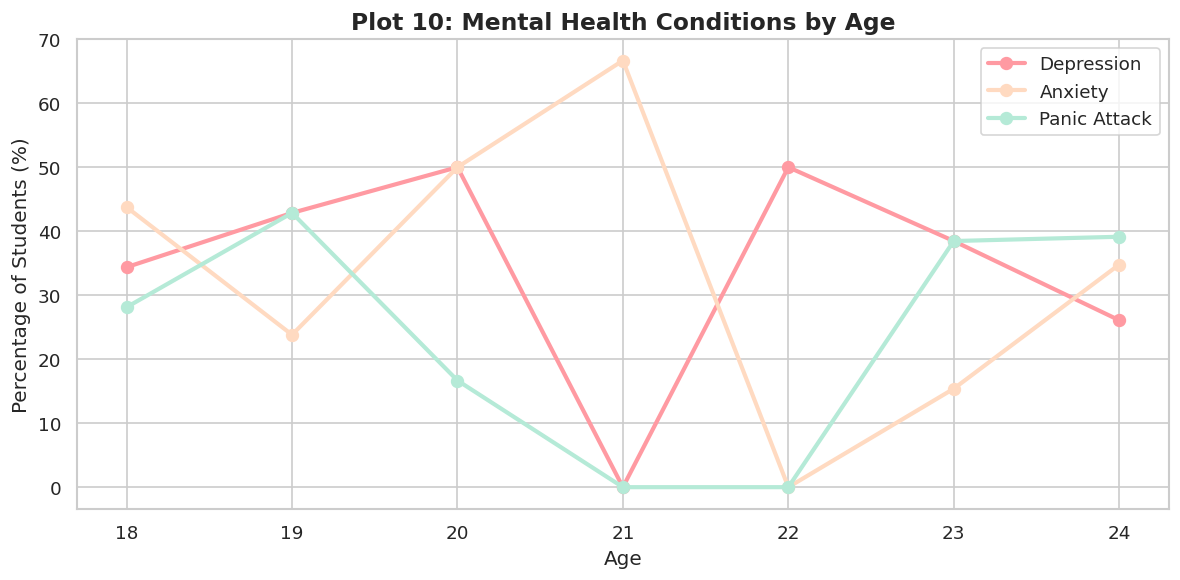


💡 Insight: Mental health conditions fluctuate across age groups.
   Younger students (18–19) and certain older ages show peaks in anxiety and depression.


In [50]:
# ── Plot 10: Age vs Mental Health Conditions (Line Plot) ──
# Why: See how mental health conditions vary across age groups

df_binary2 = df.copy()
for col in ['Depression', 'Anxiety', 'Panic_Attack']:
    df_binary2[col] = df_binary2[col].str.lower().map({'yes': 1, 'no': 0})

age_mental = df_binary2.groupby('Age')[['Depression', 'Anxiety', 'Panic_Attack']].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors_line = ['#FF9AA2', '#FFDAC1', '#B5EAD7']
for col, color in zip(['Depression', 'Anxiety', 'Panic_Attack'], colors_line):
    ax.plot(age_mental.index, age_mental[col], marker='o', label=col.replace('_', ' '),
            color=color, linewidth=2.5, markersize=7)

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Percentage of Students (%)', fontsize=12)
ax.set_title('Plot 10: Mental Health Conditions by Age', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot10_age_vs_mental_health.png', bbox_inches='tight')
plt.show()

print('\n💡 Insight: Mental health conditions fluctuate across age groups.')
print('   Younger students (18–19) and certain older ages show peaks in anxiety and depression.')

## 6. 📝 Final Summary & Key Takeaways

| # | Visualization | Key Insight |
|---|--------------|-------------|
| 1 | Gender Pie Chart | More female respondents; females self-report more |
| 2 | Age Histogram | Most students are 18–20 years old |
| 3 | Mental Health Bar Chart | Anxiety is the most prevalent condition |
| 4 | Mental Health by Gender | Females report higher rates of all conditions |
| 5 | Year of Study vs Depression | Year 1–2 students experience more depression |
| 6 | CGPA vs Depression (Box) | Depressed students tend to have slightly lower CGPA |
| 7 | Treatment Pie Chart | Most students do NOT seek professional help |
| 8 | Correlation Heatmap | Depression and anxiety strongly co-occur |
| 9 | Course vs Depression | Some academic programs have higher depression rates |
| 10 | Age vs Conditions (Line) | Mental health issues peak in younger and mid-age students |

---

### 🔑 What Can Be Learned?

1. **Mental health is a significant concern** among university students, with anxiety being the most widespread issue.
2. **Early university years** (Year 1–2) are particularly vulnerable periods for students.
3. **Gender differences** exist — female students report more mental health issues, possibly reflecting greater openness to self-reporting.
4. **Academic performance (CGPA)** is modestly associated with depression, but is not the sole predictor.
5. **Treatment-seeking is low** — universities need to improve accessibility and awareness of mental health resources.
6. **Co-occurrence is common** — students with depression are very likely to also experience anxiety or panic attacks.
